# Part B - Exploratory Data Analysis for Second-Hand Car Prices
# Done: By Mohamed Aymane Chahboune


- understand the dataset
- visualize the main variables
- extract useful insights
- prepare a clean starting point for modeling

The notebook uses the CSV file already present in this folder: `moteur_ma_listings.csv`.


In [ ]:
# Install the core EDA stack if it is missing.
%pip install pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11


## 1. Load the data

We keep the original dataset intact and create a working copy only for exploratory analysis.


In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/aymane369/car_price_analysis/main/moteur_ma_listings.csv"
df = pd.read_csv(url)
work = df.copy()

# Convert the numeric columns explicitly so the notebook is robust if the CSV changes slightly.
for col in ["year", "price_mad", "mileage_km"]:
    work[col] = pd.to_numeric(work[col], errors="coerce")

display(work.head())
print(f"Shape: {work.shape[0]:,} rows x {work.shape[1]} columns")
print("\nColumns:")
print(list(work.columns))


,brand_model,year,price_mad,mileage_km,fuel_type,transmission,city,listing_url
0,Dacia Dokker,2020.0,70000.0,85000,Diesel,Manuelle,Kénitra,https://www.moteur.ma/fr/voiture/achat-voiture...
1,Lexus NX,2018.0,293000.0,107105,Diesel,Automatique,Casablanca,https://www.moteur.ma/fr/voiture/achat-voiture...
2,Land Rover Range Rover Evoque,2015.0,170000.0,118900,Diesel,Automatique,Casablanca,https://www.moteur.ma/fr/voiture/achat-voiture...
3,Jeep Renegade,2015.0,135000.0,123006,Diesel,Manuelle,Casablanca,https://www.moteur.ma/fr/voiture/achat-voiture...
4,Nissan Qashqai,2019.0,188000.0,107000,Diesel,Manuelle,Casablanca,https://www.moteur.ma/fr/voiture/achat-voiture...


Shape: 38,868 rows x 8 columns

Columns:
['brand_model', 'year', 'price_mad', 'mileage_km', 'fuel_type', 'transmission', 'city', 'listing_url']


## 2. Data overview and quality check

This section checks missing values, duplicates, and basic summary statistics.


In [ ]:
work.info()

missing = work.isna().sum().sort_values(ascending=False)
summary = work[["year", "price_mad", "mileage_km"]].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

print("Missing values:")
display(missing.to_frame("missing_count"))

print("Basic numeric summary:")
display(summary)

print("Duplicate listing URLs:", work["listing_url"].duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38868 entries, 0 to 38867
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand_model   38868 non-null  object 
 1   year          38757 non-null  float64
 2   price_mad     36214 non-null  float64
 3   mileage_km    38868 non-null  int64  
 4   fuel_type     38851 non-null  object 
 5   transmission  38792 non-null  object 
 6   city          33126 non-null  object 
 7   listing_url   38868 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 2.4+ MB
Missing values:


,missing_count
city,5742
price_mad,2654
year,111
transmission,76
fuel_type,17
brand_model,0
mileage_km,0
listing_url,0


Basic numeric summary:


,year,price_mad,mileage_km
count,38757.000000,3.621400e+04,3.886800e+04
mean,2013.920298,2.174430e+05,4.072050e+05
std,7.254093,6.531637e+06,2.205571e+07
min,1940.000000,1.000000e+00,0.000000e+00
1%,1991.000000,2.500000e+04,0.000000e+00
5%,2001.000000,4.300000e+04,0.000000e+00
25%,2010.000000,8.000000e+04,6.000000e+04
50%,2015.000000,1.300000e+05,1.200000e+05
75%,2019.000000,2.100000e+05,1.870000e+05
95%,2023.000000,4.200000e+05,3.000000e+05


Duplicate listing URLs: 0


## 3. Univariate analysis

We inspect the distributions of price, mileage, year, fuel type, transmission, city, and the most common brand/model names.


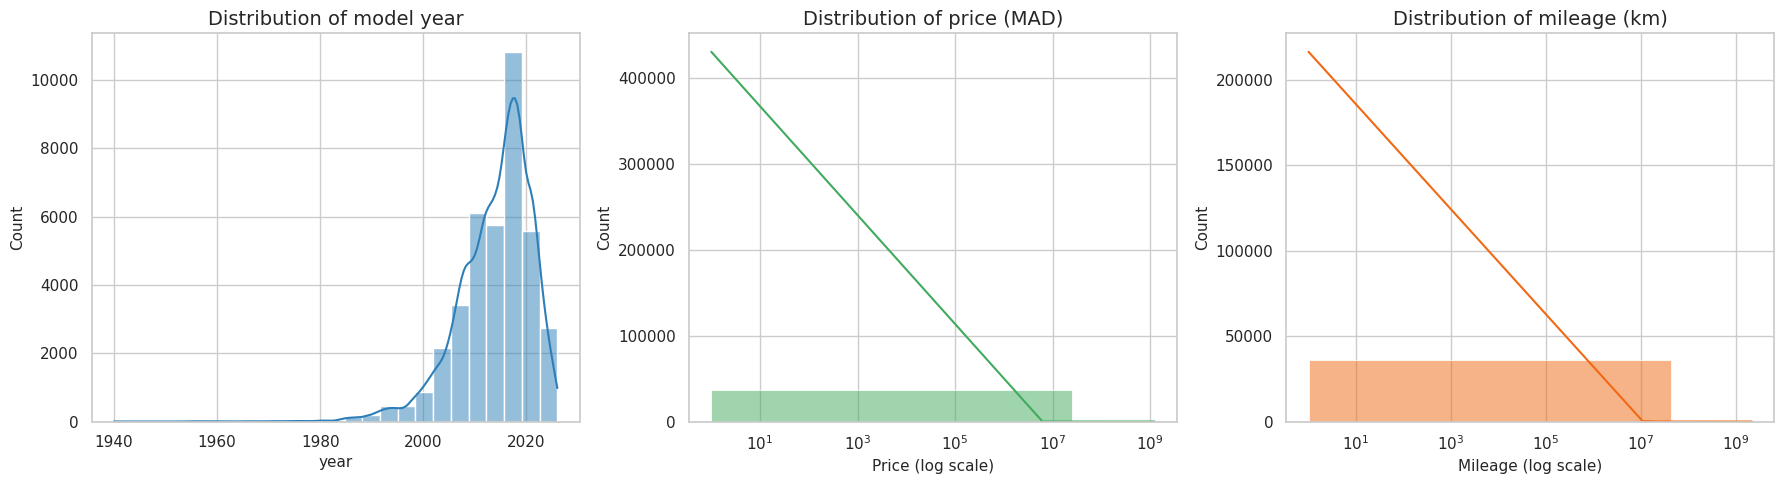

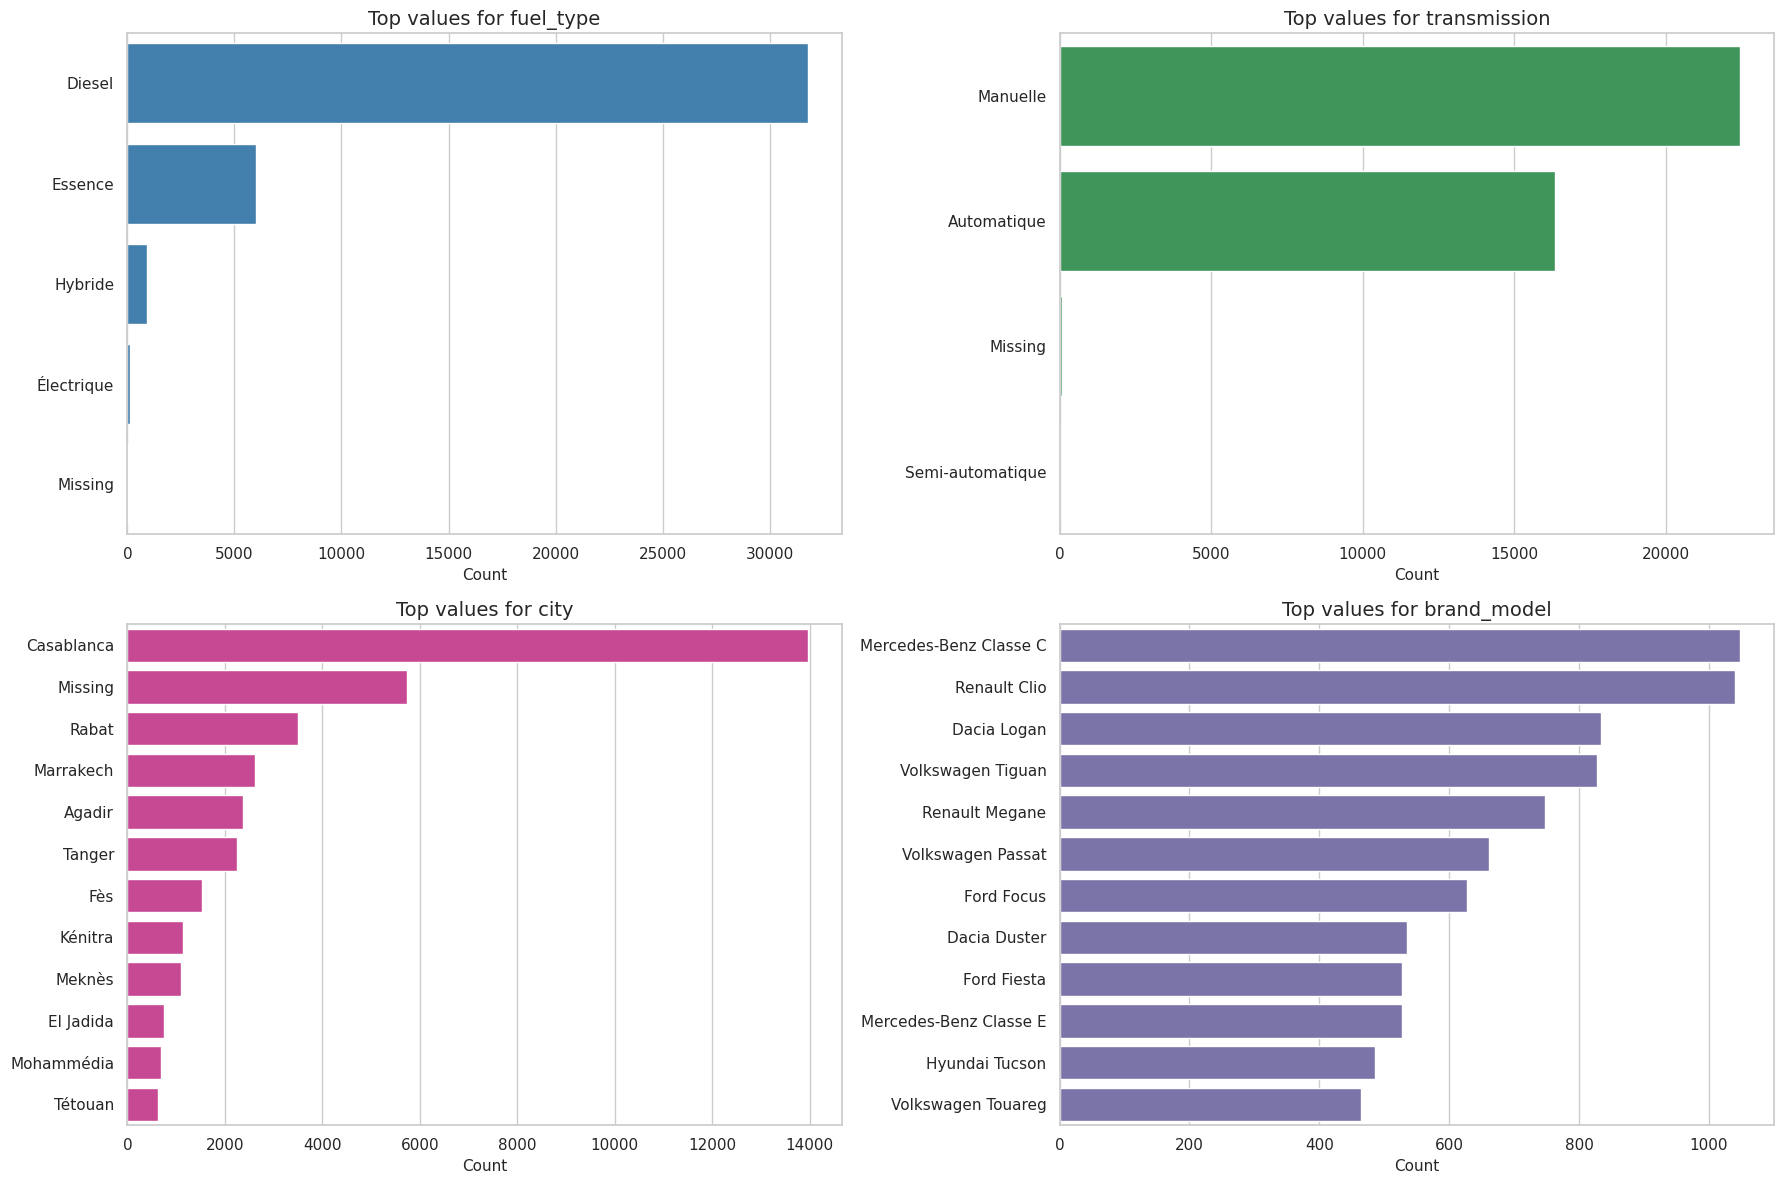

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(work["year"], bins=25, kde=True, ax=axes[0], color="#2c7fb8")
axes[0].set_title("Distribution of model year")

sns.histplot(work["price_mad"].dropna().loc[lambda s: s > 0], bins=50, kde=True, ax=axes[1], color="#41ab5d")
axes[1].set_title("Distribution of price (MAD)")
axes[1].set_xscale("log")
axes[1].set_xlabel("Price (log scale)")

sns.histplot(work["mileage_km"].dropna().loc[lambda s: s > 0], bins=50, kde=True, ax=axes[2], color="#f16913")
axes[2].set_title("Distribution of mileage (km)")
axes[2].set_xscale("log")
axes[2].set_xlabel("Mileage (log scale)")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for ax, col, color in [
    (axes[0, 0], "fuel_type", "#3182bd"),
    (axes[0, 1], "transmission", "#31a354"),
    (axes[1, 0], "city", "#dd3497"),
    (axes[1, 1], "brand_model", "#756bb1"),
]:
    top_values = work[col].fillna("Missing").value_counts().head(12)
    sns.barplot(x=top_values.values, y=top_values.index, ax=ax, color=color)
    ax.set_title(f"Top values for {col}")
    ax.set_xlabel("Count")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

## 4. Bivariate analysis

These plots help us understand how price changes with mileage, year, fuel type, transmission, and city.


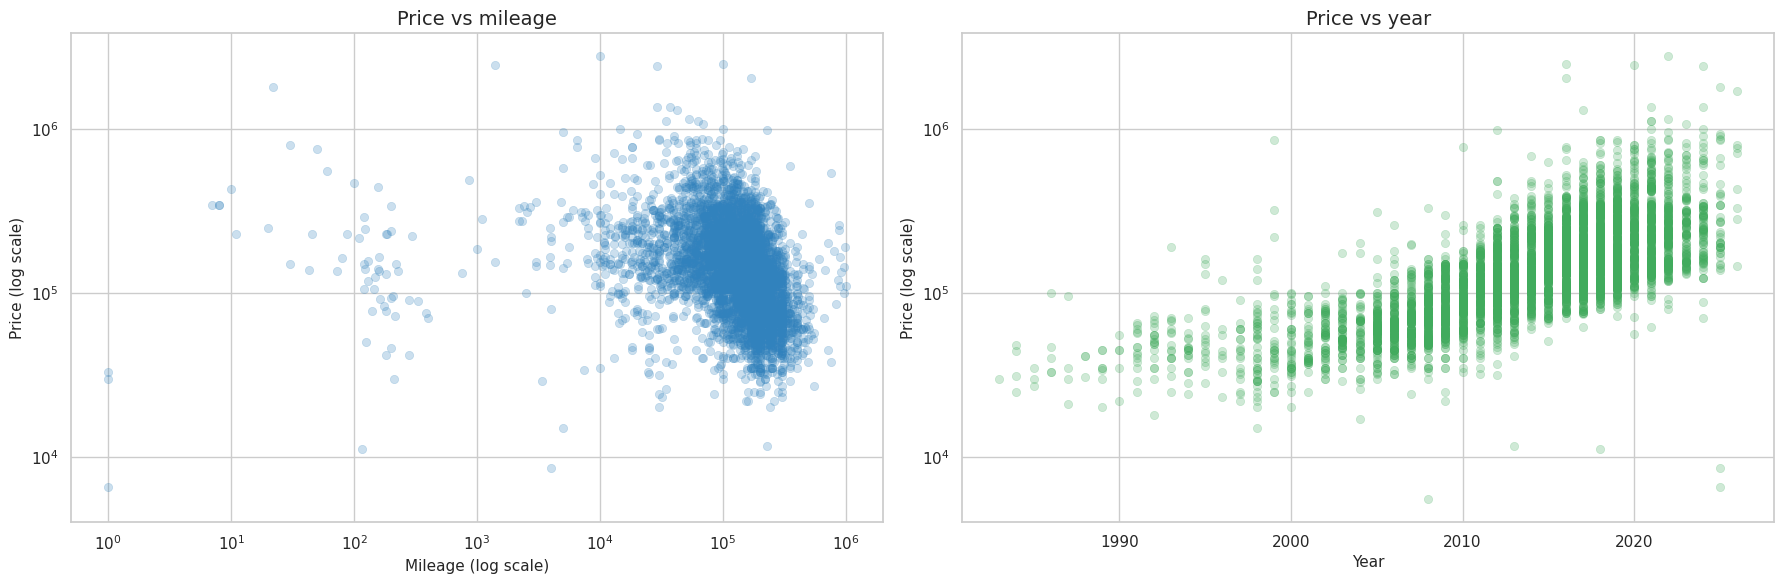

/tmp/ipykernel_18951/2586234292.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=viz, x="fuel_type", y="price_mad", ax=axes[0], palette="Blues")
/tmp/ipykernel_18951/2586234292.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=viz, x="transmission", y="price_mad", ax=axes[1], palette="Greens")
/tmp/ipykernel_18951/2586234292.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=viz[viz["city"].fillna("Missing").isin(city_top)], x="city", y="price_mad", ax=axes[2], palette="Reds")


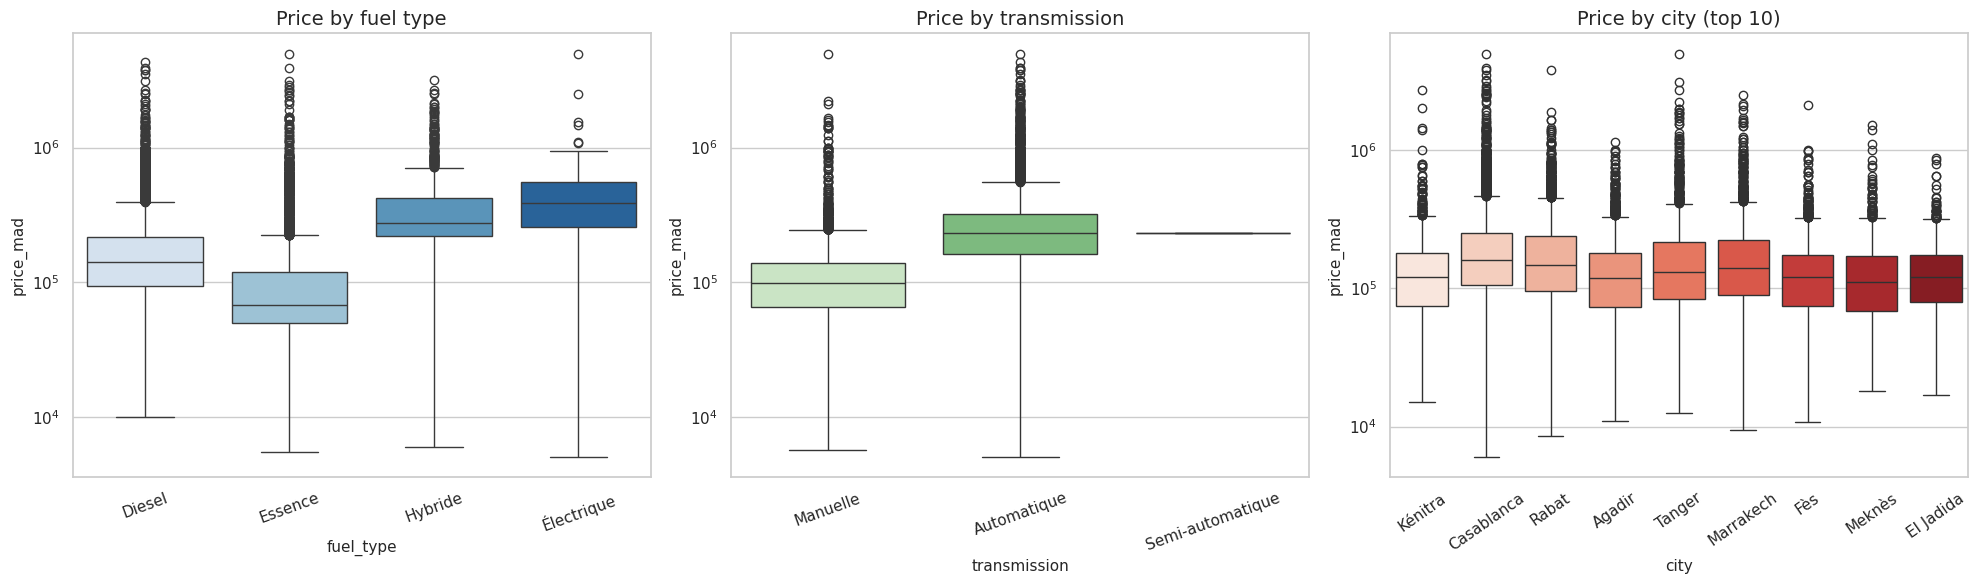

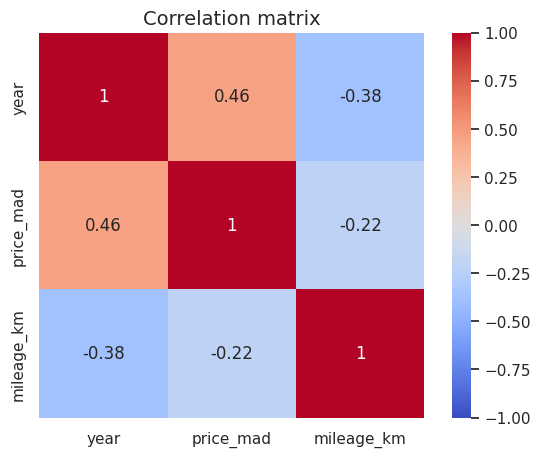

In [ ]:
# Use a cleaned view for visualization only.
# We remove obvious impossible values so the plots are readable.
viz = work.copy()
viz = viz.dropna(subset=["price_mad", "year", "mileage_km"])
viz = viz[(viz["price_mad"] >= 5000) & (viz["price_mad"] <= 5_000_000)]
viz = viz[(viz["mileage_km"] >= 0) & (viz["mileage_km"] <= 1_000_000)]
viz = viz[viz["year"].between(1980, 2026)]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sample = viz.sample(min(len(viz), 5000), random_state=42)
sns.scatterplot(data=sample, x="mileage_km", y="price_mad", alpha=0.25, ax=axes[0], color="#3182bd", edgecolor=None)
axes[0].set_title("Price vs mileage")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Mileage (log scale)")
axes[0].set_ylabel("Price (log scale)")

sns.scatterplot(data=sample, x="year", y="price_mad", alpha=0.25, ax=axes[1], color="#41ab5d", edgecolor=None)
axes[1].set_title("Price vs year")
axes[1].set_yscale("log")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Price (log scale)")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.boxplot(data=viz, x="fuel_type", y="price_mad", ax=axes[0], palette="Blues")
axes[0].set_yscale("log")
axes[0].set_title("Price by fuel type")
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=viz, x="transmission", y="price_mad", ax=axes[1], palette="Greens")
axes[1].set_yscale("log")
axes[1].set_title("Price by transmission")
axes[1].tick_params(axis='x', rotation=20)

city_top = viz["city"].fillna("Missing").value_counts().head(10).index
sns.boxplot(data=viz[viz["city"].fillna("Missing").isin(city_top)], x="city", y="price_mad", ax=axes[2], palette="Reds")
axes[2].set_yscale("log")
axes[2].set_title("Price by city (top 10)")
axes[2].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()

corr = viz[["year", "price_mad", "mileage_km"]].corr(numeric_only=True)
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlation matrix")
plt.show()


## 5. Useful insights for the report

The next cell surfaces a few summary tables that you can mention in your write-up.


In [ ]:
insight_df = viz.copy()

print("Median price by fuel type:")
display(insight_df.groupby("fuel_type", dropna=False)["price_mad"].median().sort_values(ascending=False).to_frame("median_price_mad"))

print("Median price by transmission:")
display(insight_df.groupby("transmission", dropna=False)["price_mad"].median().sort_values(ascending=False).to_frame("median_price_mad"))

brand_stats = (
    insight_df.groupby("brand_model")
    .agg(listings=("price_mad", "size"), median_price_mad=("price_mad", "median"))
    .query("listings >= 100")
    .sort_values("median_price_mad", ascending=False)
)

print("Top brands/models by median price (minimum 100 listings):")
display(brand_stats.head(15))

print("Most common cities:")
display(insight_df["city"].fillna("Missing").value_counts().head(10).to_frame("count"))

print("Most common fuel types and transmissions:")
display(insight_df[["fuel_type", "transmission"]].fillna("Missing").agg(lambda s: s.value_counts().head(5)))


Median price by fuel type:


,median_price_mad
fuel_type,
Électrique,390000.0
Hybride,275000.0
Diesel,140000.0
NaN,103000.0
Essence,68000.0


Median price by transmission:


,median_price_mad
transmission,
Automatique,230000.0
Semi-automatique,230000.0
NaN,199000.0
Manuelle,98000.0


Top brands/models by median price (minimum 100 listings):


,listings,median_price_mad
brand_model,,
Mercedes-Benz Classe GLC,115,540000.0
Porsche Cayenne,112,465000.0
Land Rover Range Rover Sport,275,390000.0
Audi Q3,148,337500.0
Audi Q5,319,330000.0
Mercedes-Benz Classe CLA,144,286500.0
BMW X5,159,280000.0
BMW Série 4,118,270000.0
Land Rover Range Rover Evoque,354,270000.0


Most common cities:


,count
city,
Casablanca,12091
Missing,5632
Rabat,3252
Marrakech,2395
Agadir,2253
Tanger,2067
Fès,1477
Kénitra,1130
Meknès,1067


Most common fuel types and transmissions:


,fuel_type,transmission
Automatique,NaN,13936.0
Diesel,29711.0,NaN
Essence,5430.0,NaN
Hybride,627.0,NaN
Manuelle,NaN,21891.0
Missing,2.0,21.0
Semi-automatique,NaN,1.0
Électrique,79.0,NaN


## 6. Modeling preparation notes

### Quick takeaways from the EDA

- The dataset is dominated by **diesel** and **manual** cars, which also makes those groups the most useful for comparison.
- On the cleaned analysis subset, **newer cars tend to be more expensive**, while **higher mileage tends to reduce price**.
- **Automatic** cars generally sit in a higher price range than manual cars.
- **Casablanca** appears as the most represented city in the listings, so location is likely an important modeling feature.
- High-end SUVs and premium brands/models show the highest median prices, while older compact models occupy the lower end of the market.

From the EDA, the most useful candidate features for modeling are:

- `brand_model`
- `year`
- `mileage_km`
- `fuel_type`
- `transmission`
- `city`

Target variable:

- `price_mad`

Before modeling, the next steps should be:

- handle missing values
- treat outliers
- encode categorical variables
- transform skewed numerical variables if needed
- split data into train and test sets


---

# Part C — Data Cleaning & Preprocessing / Done by "CHAAIBI NOUAMAN"

Steps:
1. Handle Missing Values  
2. Handle Outliers  
3. Feature Engineering  
4. Encode Categorical Variables  
5. Feature Selection  
6. Data Transformation — Normalization & Standardization


## Setup — Libraries

In [ ]:
%pip install scikit-learn scipy --quiet

from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.feature_selection import mutual_info_regression

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

---

## C.1 — Handle Missing Values

Part B revealed the following missing values:

| Column | Missing | % | Strategy |
|--------|---------|---|----------|
| `city` | 5 742 | 14.8 % | Fill with `'Unknown'` — keep rows, encode later |
| `price_mad` | 2 654 | 6.8 % | **Drop rows** — cannot train without the target |
| `year` | 111 | 0.3 % | Fill with **median** year |
| `transmission` | 76 | 0.2 % | Fill with **mode** (`Manuelle`) |
| `fuel_type` | 17 | 0.04 % | Fill with **mode** (`Diesel`) |
| `listing_url` | 0 | — | **Drop column** — no predictive value |

> We never impute the target variable — rows with missing `price_mad` are removed.


In [ ]:
# ── Starting point ────────────────────────────────────────
print("Missing values BEFORE handling:")
display(work.isna().sum().to_frame("missing").query("missing > 0"))
print(f"Shape: {work.shape}")


Missing values BEFORE handling:


,missing
year,111
price_mad,2654
fuel_type,17
transmission,76
city,5742


Shape: (38868, 8)


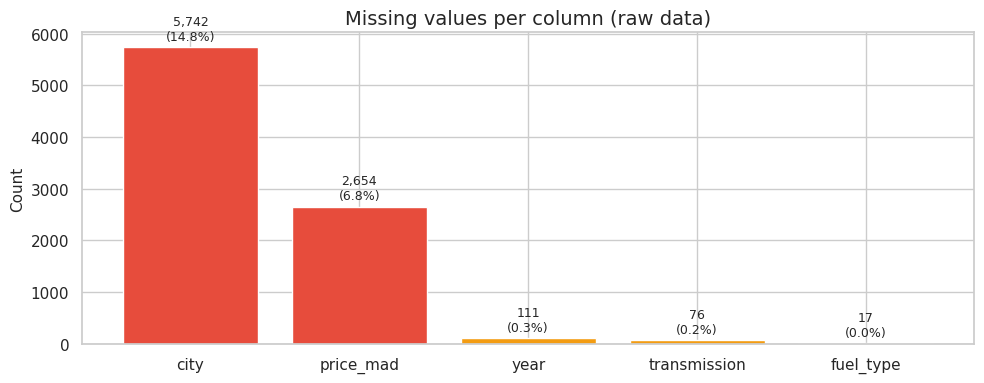

In [ ]:
# ── Visualise missing values ──────────────────────────────
miss = work.isna().sum().sort_values(ascending=False)
miss = miss[miss > 0]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(miss.index, miss.values, color=["#e74c3c" if v > 1000 else "#f39c12" for v in miss.values])
ax.bar_label(bars, labels=[f"{v:,}\n({v/len(work)*100:.1f}%)" for v in miss.values], padding=3, fontsize=9)
ax.set_title("Missing values per column (raw data)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


In [ ]:
# ── Step 1 — Drop non-predictive column ──────────────────
work.drop(columns=["listing_url"], inplace=True)
print("✓ Dropped 'listing_url'")

# ── Step 2 — Drop rows with missing target ───────────────
before = len(work)
work.dropna(subset=["price_mad"], inplace=True)
print(f"✓ Dropped {before - len(work):,} rows with missing price_mad")

# ── Step 3 — Fill year with median ───────────────────────
median_year = work["year"].median()
work["year"].fillna(median_year, inplace=True)
print(f"✓ Filled missing 'year' with median ({int(median_year)})")

# ── Step 4 — Fill fuel_type with mode ────────────────────
mode_fuel = work["fuel_type"].mode()[0]
work["fuel_type"].fillna(mode_fuel, inplace=True)
print(f"✓ Filled missing 'fuel_type' with mode ('{mode_fuel}')")

# ── Step 5 — Fill transmission with mode ─────────────────
mode_trans = work["transmission"].mode()[0]
work["transmission"].fillna(mode_trans, inplace=True)
print(f"✓ Filled missing 'transmission' with mode ('{mode_trans}')")

# ── Step 6 — Fill city with 'Unknown' ────────────────────
n_city = work["city"].isna().sum()
work["city"].fillna("Unknown", inplace=True)
print(f"✓ Filled {n_city:,} missing 'city' values with 'Unknown'")

# ── Verify ───────────────────────────────────────────────
print(f"\nRemaining missing values: {work.isna().sum().sum()}")
print(f"Shape after C.1: {work.shape}")


✓ Dropped 'listing_url'
✓ Dropped 2,654 rows with missing price_mad
✓ Filled missing 'year' with median (2015)
✓ Filled missing 'fuel_type' with mode ('Diesel')
✓ Filled missing 'transmission' with mode ('Manuelle')
✓ Filled 5,675 missing 'city' values with 'Unknown'

Remaining missing values: 0
Shape after C.1: (36214, 7)


/tmp/ipykernel_18951/1120239006.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  work["year"].fillna(median_year, inplace=True)
/tmp/ipykernel_18951/1120239006.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

---

## C.2 — Handle Outliers

Part B used a `viz` subset with loose thresholds (price 5k–5M, mileage 0–1M, year 1980–2026)  
just to make the EDA plots readable. Here we apply **rigorous, justified filters** for modeling.

| Feature | Issue found in EDA | Filter | Method |
|---------|-------------------|--------|--------|
| `year` | Values as low as 1940 (vintage, not second-hand market) | Keep **1990–2025** | Hard filter |
| `mileage_km` | Values equal to `2 147 483 647` (INT overflow) | Keep **≤ 500 000 km** | Hard filter |
| `price_mad` | Min = 1 MAD, Max = 1.2 billion MAD | Keep **5 000 – 5 000 000 MAD** then Winsorise at 1 %–99 % | Hard filter + Winsorisation |

> **Winsorisation** clips extreme values to the 1st / 99th percentile instead of deleting them,  
> so we lose no rows — only the extreme values are capped.


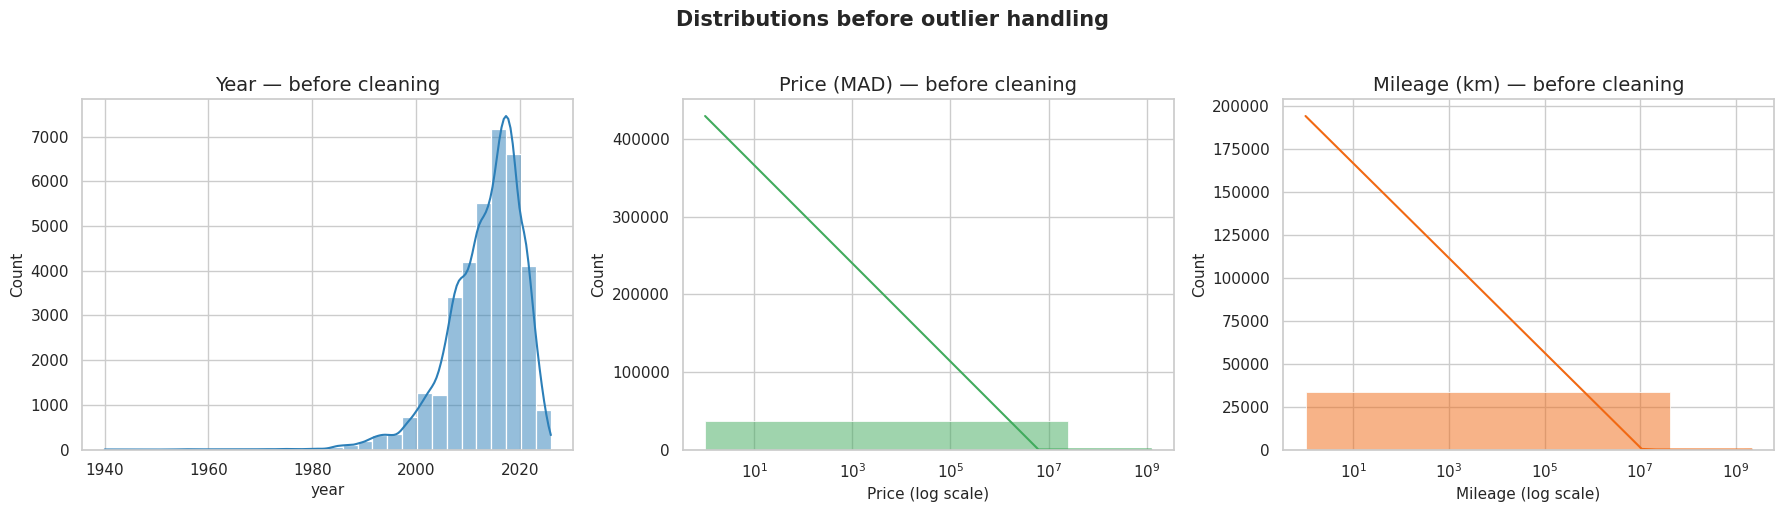

In [ ]:
# ── Distributions BEFORE outlier removal ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(work["year"], bins=30, kde=True, ax=axes[0], color="#2c7fb8")
axes[0].set_title("Year — before cleaning")

sns.histplot(work["price_mad"].loc[lambda s: s > 0], bins=50, kde=True, ax=axes[1], color="#41ab5d")
axes[1].set_title("Price (MAD) — before cleaning")
axes[1].set_xscale("log")
axes[1].set_xlabel("Price (log scale)")

sns.histplot(work["mileage_km"].loc[lambda s: s > 0], bins=50, kde=True, ax=axes[2], color="#f16913")
axes[2].set_title("Mileage (km) — before cleaning")
axes[2].set_xscale("log")
axes[2].set_xlabel("Mileage (log scale)")

plt.suptitle("Distributions before outlier handling", y=1.02, fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


In [ ]:
# ── Hard filters ─────────────────────────────────────────
before = len(work)

# Year
work = work[(work["year"] >= 1990) & (work["year"] <= 2025)]
print(f"✓ Year [1990–2025]:  removed {before - len(work):,} rows — shape now {work.shape}")

before = len(work)
# Mileage
work = work[work["mileage_km"] <= 500_000]
print(f"✓ Mileage [0–500 000]: removed {before - len(work):,} rows — shape now {work.shape}")

before = len(work)
# Price
work = work[(work["price_mad"] >= 5_000) & (work["price_mad"] <= 5_000_000)]
print(f"✓ Price [5 000–5 000 000]: removed {before - len(work):,} rows — shape now {work.shape}")

# ── Winsorise price at 1 %–99 % ──────────────────────────
p01 = work["price_mad"].quantile(0.01)
p99 = work["price_mad"].quantile(0.99)
work["price_mad"] = work["price_mad"].clip(lower=p01, upper=p99)
print(f"✓ Winsorised price to [{p01:,.0f} – {p99:,.0f}] MAD (1 %–99 % percentiles)")

print(f"\nFinal shape after C.2: {work.shape}")


✓ Year [1990–2025]:  removed 354 rows — shape now (35860, 7)
✓ Mileage [0–500 000]: removed 281 rows — shape now (35579, 7)
✓ Price [5 000–5 000 000]: removed 170 rows — shape now (35409, 7)
✓ Winsorised price to [31,000 – 750,000] MAD (1 %–99 % percentiles)

Final shape after C.2: (35409, 7)


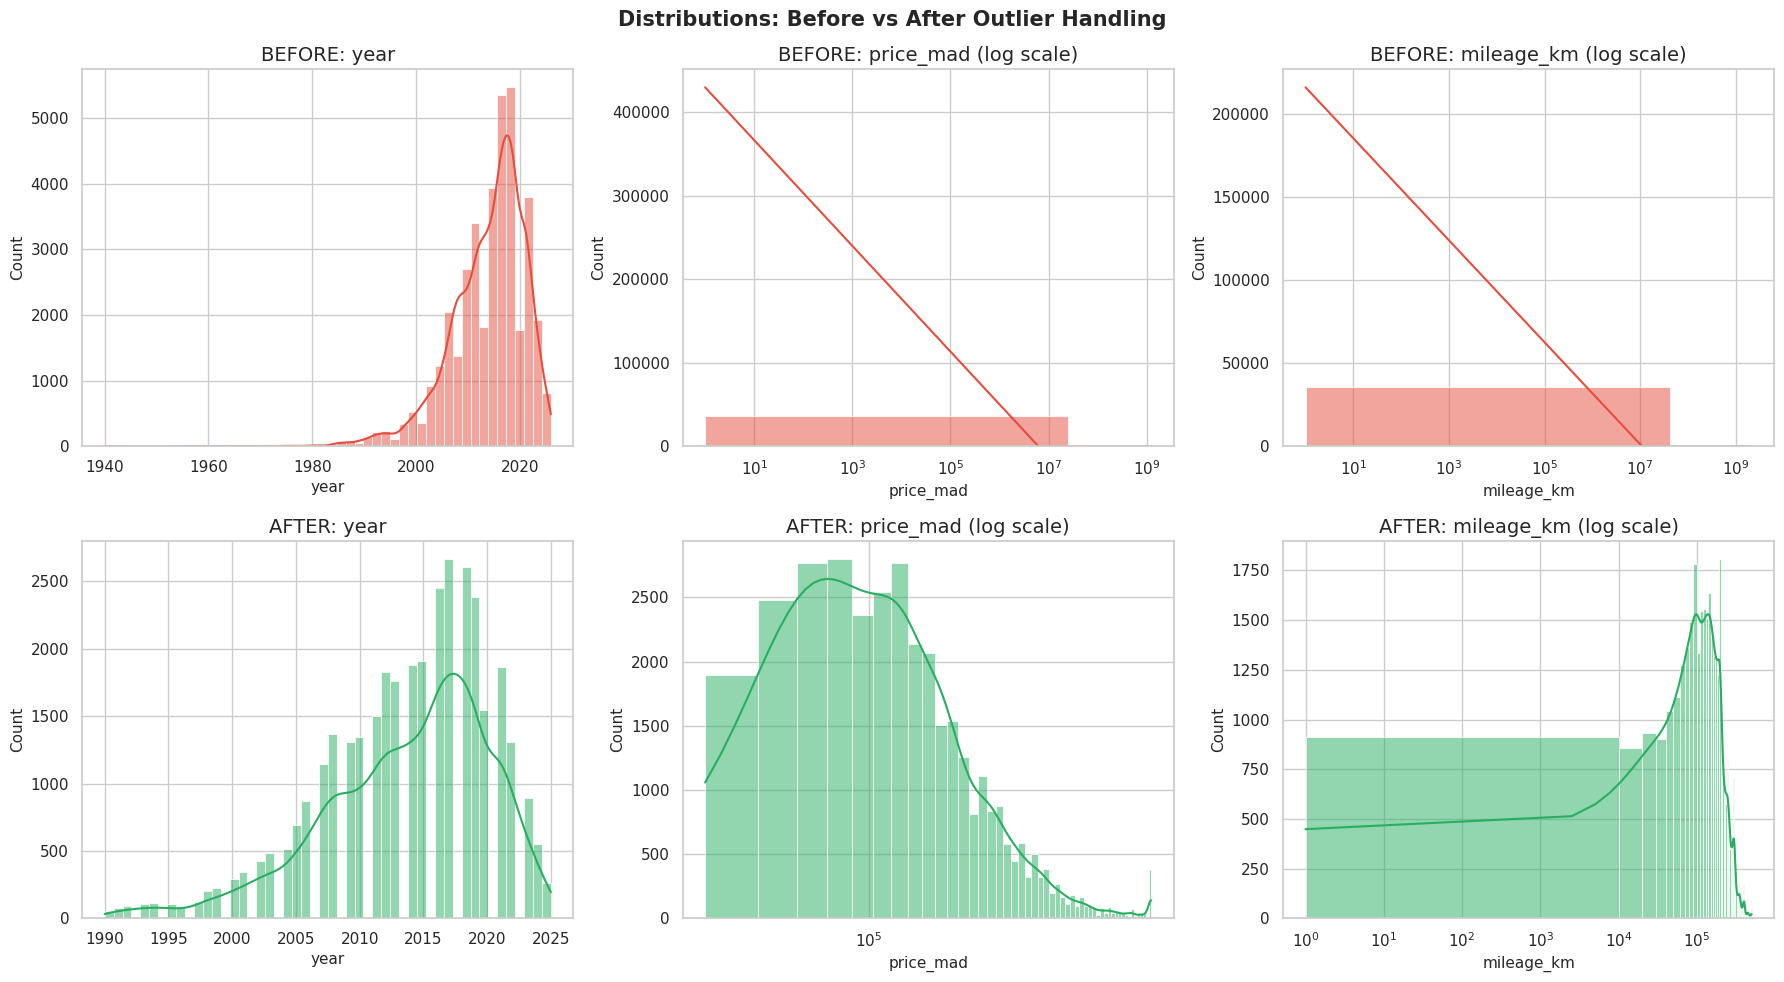

In [ ]:
# ── Before vs After comparison (boxplots) ────────────────
df_raw_viz = df.copy()
for col in ["year", "price_mad", "mileage_km"]:
    df_raw_viz[col] = pd.to_numeric(df_raw_viz[col], errors="coerce")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Distributions: Before vs After Outlier Handling", fontsize=15, fontweight="bold")

pairs = [("year", False), ("price_mad", True), ("mileage_km", True)]

for col_idx, (col, use_log) in enumerate(pairs):
    for row_idx, (data, label, color) in enumerate([
        (df_raw_viz[col].dropna(), "BEFORE", "#e74c3c"),
        (work[col].dropna(), "AFTER",  "#27ae60"),
    ]):
        ax = axes[row_idx][col_idx]
        valid = data[data > 0] if use_log else data
        sns.histplot(valid, bins=50, kde=True, ax=ax, color=color)
        ax.set_title(f"{label}: {col}" + (" (log scale)" if use_log else ""))
        if use_log:
            ax.set_xscale("log")

plt.tight_layout()
plt.show()


---

## C.3 — Feature Engineering

Based on Part B insights we derive new features that improve the signal for modeling:

| New feature | Formula | Insight from EDA |
|-------------|---------|-----------------|
| `car_age` | 2025 − `year` | Age correlated with price (EDA scatterplot) |
| `brand` | First token of `brand_model` | Brand-level price differences shown in insight table |
| `mileage_per_year` | `mileage_km` / max(`car_age`, 1) | Captures usage intensity, complements raw mileage |
| `is_luxury` | 1 if brand is premium | Premium brands clustered in high-price range in EDA |
| `region` | City → major city or `Other` / `Unknown` | Casablanca dominates; reduces cardinality from 50+ to 10 |


In [ ]:
CURRENT_YEAR = 2025

# ── car_age ───────────────────────────────────────────────
work["car_age"] = CURRENT_YEAR - work["year"].astype(int)

# ── brand ─────────────────────────────────────────────────
work["brand"] = work["brand_model"].str.split().str[0]

# ── mileage_per_year ──────────────────────────────────────
work["mileage_per_year"] = work["mileage_km"] / work["car_age"].clip(lower=1)

# ── is_luxury ─────────────────────────────────────────────
LUXURY_BRANDS = {
    "Mercedes-Benz", "BMW", "Audi", "Porsche", "Lexus",
    "Land", "Jaguar", "Maserati", "Ferrari", "Bentley",
    "Cadillac", "Lincoln", "Infiniti", "Volvo", "Genesis"
}
work["is_luxury"] = work["brand"].isin(LUXURY_BRANDS).astype(int)

# ── region ────────────────────────────────────────────────
MAJOR_CITIES = {"Casablanca", "Rabat", "Marrakech", "Agadir",
                "Tanger", "Fès", "Kénitra", "Meknès"}
work["region"] = work["city"].apply(
    lambda x: x if x in MAJOR_CITIES else ("Unknown" if x == "Unknown" else "Other")
)

print("✅ New features created:")
print(f"   car_age          — range [{work['car_age'].min()}, {work['car_age'].max()}] years")
print(f"   brand            — {work['brand'].nunique()} unique brands")
print(f"   mileage_per_year — median {work['mileage_per_year'].median():,.0f} km/year")
print(f"   is_luxury        — {work['is_luxury'].sum():,} luxury listings ({work['is_luxury'].mean()*100:.1f}%)")
print(f"   region           — categories: {sorted(work['region'].unique())}")
display(work[["brand_model", "year", "car_age", "brand", "mileage_km",
              "mileage_per_year", "is_luxury", "region", "price_mad"]].head(5))


✅ New features created:
   car_age          — range [0, 35] years
   brand            — 81 unique brands
   mileage_per_year — median 12,885 km/year
   is_luxury        — 7,852 luxury listings (22.2%)
   region           — categories: ['Agadir', 'Casablanca', 'Fès', 'Kénitra', 'Marrakech', 'Meknès', 'Other', 'Rabat', 'Tanger', 'Unknown']


,brand_model,year,car_age,brand,mileage_km,mileage_per_year,is_luxury,region,price_mad
0,Dacia Dokker,2020.0,5,Dacia,85000,17000.000000,0,Kénitra,70000.0
1,Lexus NX,2018.0,7,Lexus,107105,15300.714286,1,Casablanca,293000.0
2,Land Rover Range Rover Evoque,2015.0,10,Land,118900,11890.000000,1,Casablanca,170000.0
3,Jeep Renegade,2015.0,10,Jeep,123006,12300.600000,0,Casablanca,135000.0
4,Nissan Qashqai,2019.0,6,Nissan,107000,17833.333333,0,Casablanca,188000.0


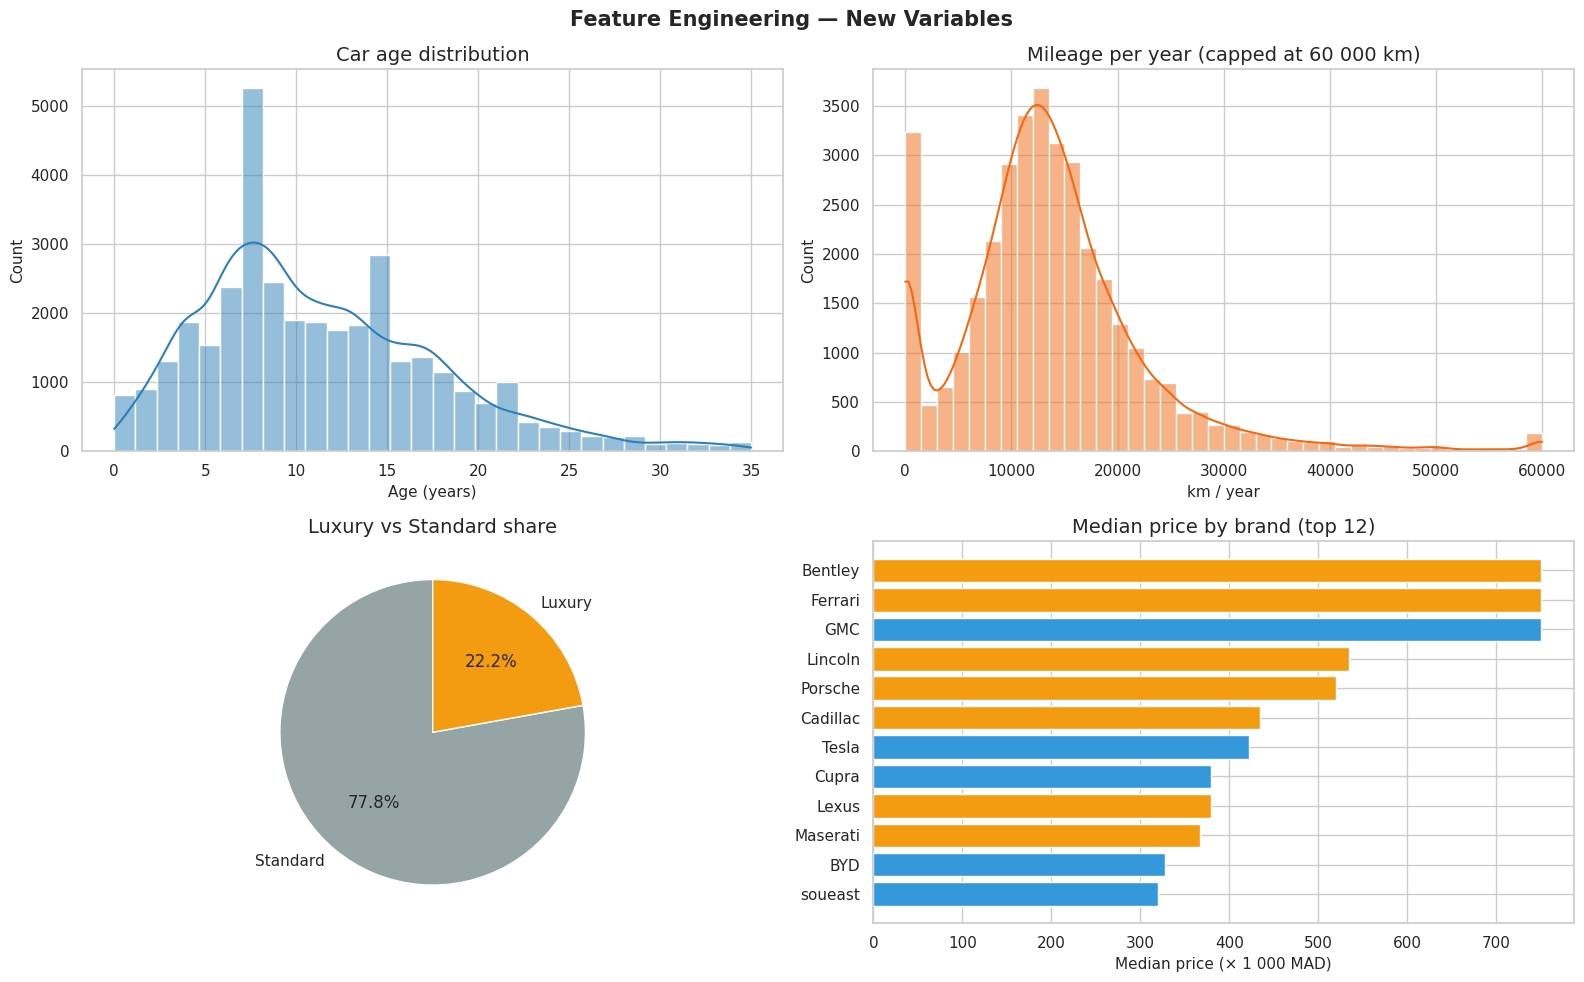

In [ ]:
# ── Feature engineering visualisations ───────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Feature Engineering — New Variables", fontsize=15, fontweight="bold")

# car_age
sns.histplot(work["car_age"], bins=30, kde=True, ax=axes[0, 0], color="#2c7fb8")
axes[0, 0].set_title("Car age distribution")
axes[0, 0].set_xlabel("Age (years)")

# mileage_per_year (capped for readability)
sns.histplot(work["mileage_per_year"].clip(0, 60_000), bins=40, kde=True,
             ax=axes[0, 1], color="#f16913")
axes[0, 1].set_title("Mileage per year (capped at 60 000 km)")
axes[0, 1].set_xlabel("km / year")

# is_luxury
lux_counts = work["is_luxury"].value_counts()
axes[1, 0].pie(lux_counts, labels=["Standard", "Luxury"],
               autopct="%1.1f%%", colors=["#95a5a6", "#f39c12"], startangle=90)
axes[1, 0].set_title("Luxury vs Standard share")

# Median price by brand (top 12)
brand_price = (work.groupby("brand")["price_mad"]
               .median().sort_values(ascending=False).head(12))
colors_bar = ["#f39c12" if b in LUXURY_BRANDS else "#3498db" for b in brand_price.index]
axes[1, 1].barh(brand_price.index[::-1], brand_price.values[::-1] / 1000, color=colors_bar[::-1])
axes[1, 1].set_title("Median price by brand (top 12)")
axes[1, 1].set_xlabel("Median price (× 1 000 MAD)")

plt.tight_layout()
plt.show()


---

## C.4 — Encode Categorical Variables

| Variable | Cardinality | Method | Reason |
|----------|------------|--------|--------|
| `fuel_type` | 4 | **One-Hot Encoding** | Low cardinality, no ordinal order |
| `transmission` | 2 | **Binary (0/1)** | Only 2 meaningful classes |
| `region` | 10 | **Label Encoding** | Manageable cardinality |
| `brand` | 50 + | **Target Encoding** (mean price per brand) | High cardinality; avoids OHE explosion; encodes brand prestige |

> `brand_model` is dropped after extracting `brand` — it has hundreds of levels and is  
> already captured by `brand` + `car_age` + `mileage_km`.


In [ ]:
# ── One-Hot Encoding — fuel_type ─────────────────────────
fuel_dummies = pd.get_dummies(work["fuel_type"], prefix="fuel")
print(f"✓ fuel_type OHE — columns: {list(fuel_dummies.columns)}")

# ── Binary Encoding — transmission ───────────────────────
work["transmission_enc"] = (work["transmission"] == "Automatique").astype(int)
print("✓ transmission_enc — 0 = Manuelle, 1 = Automatique")
print(f"   {work['transmission_enc'].value_counts().to_dict()}")

# ── Label Encoding — region ───────────────────────────────
region_le = LabelEncoder()
work["region_enc"] = region_le.fit_transform(work["region"])
print(f"\n✓ region_enc — mapping:")
for cls, val in zip(region_le.classes_, region_le.transform(region_le.classes_)):
    print(f"   {cls:15s} → {val}")

# ── Target Encoding — brand ───────────────────────────────
brand_mean = work.groupby("brand")["price_mad"].mean()
work["brand_target_enc"] = work["brand"].map(brand_mean)
print(f"\n✓ brand_target_enc — mean price per brand (top 5):")
display(brand_mean.sort_values(ascending=False).head(5).apply(lambda x: f"{x:,.0f} MAD").to_frame("mean_price"))

# ── Assemble encoded dataframe ────────────────────────────
features_base = ["car_age", "mileage_km", "mileage_per_year",
                 "is_luxury", "transmission_enc", "region_enc", "brand_target_enc"]
df_enc = pd.concat([work[features_base + ["price_mad"]], fuel_dummies], axis=1)
df_enc.dropna(inplace=True)

print(f"\n Encoded dataset: {df_enc.shape[0]:,} rows × {df_enc.shape[1]} columns")
print(f"Columns: {list(df_enc.columns)}")
display(df_enc.head(3))


✓ fuel_type OHE — columns: ['fuel_Diesel', 'fuel_Essence', 'fuel_Hybride', 'fuel_Électrique']
✓ transmission_enc — 0 = Manuelle, 1 = Automatique
   {0: 21579, 1: 13830}

✓ region_enc — mapping:
   Agadir          → 0
   Casablanca      → 1
   Fès             → 2
   Kénitra         → 3
   Marrakech       → 4
   Meknès          → 5
   Other           → 6
   Rabat           → 7
   Tanger          → 8
   Unknown         → 9

✓ brand_target_enc — mean price per brand (top 5):


,mean_price
brand,
Ferrari,"750,000 MAD"
GMC,"692,500 MAD"
Bentley,"600,909 MAD"
Lincoln,"535,000 MAD"
Cadillac,"519,083 MAD"



 Encoded dataset: 35,409 rows × 12 columns
Columns: ['car_age', 'mileage_km', 'mileage_per_year', 'is_luxury', 'transmission_enc', 'region_enc', 'brand_target_enc', 'price_mad', 'fuel_Diesel', 'fuel_Essence', 'fuel_Hybride', 'fuel_Électrique']


,car_age,mileage_km,mileage_per_year,is_luxury,transmission_enc,region_enc,brand_target_enc,price_mad,fuel_Diesel,fuel_Essence,fuel_Hybride,fuel_Électrique
0,5,85000,17000.000000,0,0,3,112635.593765,70000.0,True,False,False,False
1,7,107105,15300.714286,1,1,1,423592.592593,293000.0,True,False,False,False
2,10,118900,11890.000000,1,1,1,336333.106785,170000.0,True,False,False,False


/tmp/ipykernel_18951/3054501370.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Manuelle (0)", "Automatique (1)"], y=t_counts.values,


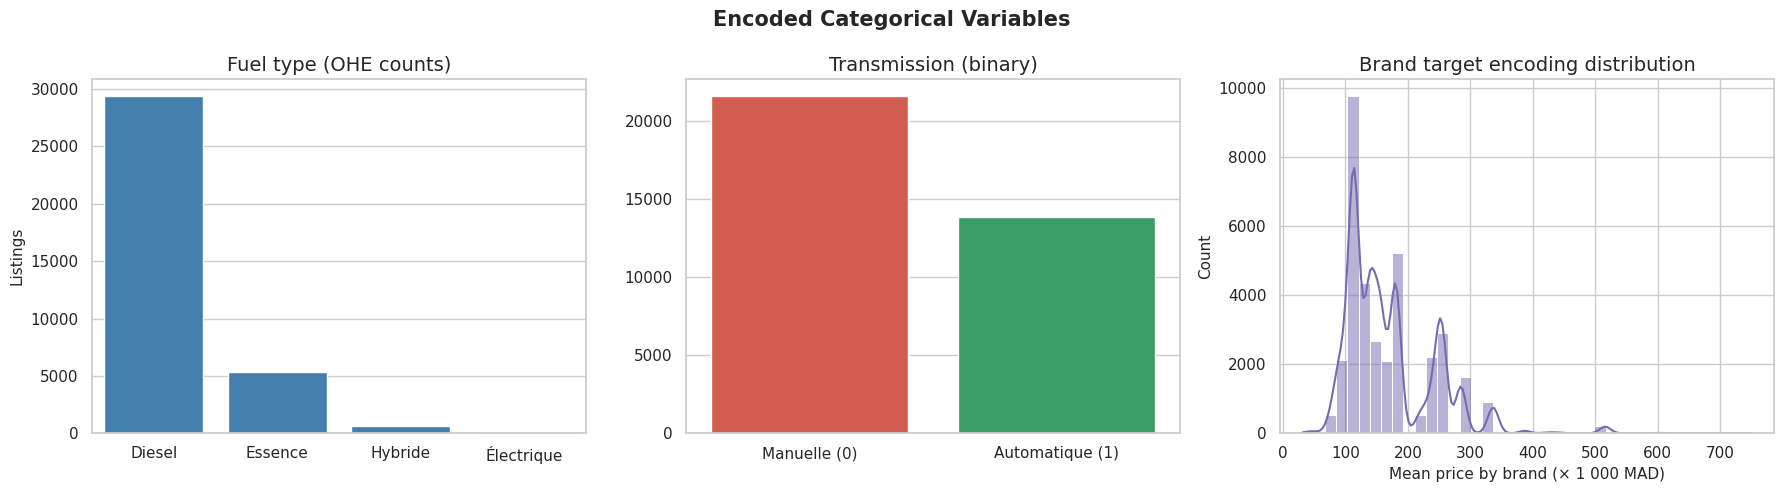

In [ ]:
# ── Encoding summary visualisation ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Encoded Categorical Variables", fontsize=15, fontweight="bold")

# fuel OHE counts
fuel_cols = [c for c in df_enc.columns if c.startswith("fuel_")]
fuel_sums = df_enc[fuel_cols].sum()
sns.barplot(x=[c.replace("fuel_", "") for c in fuel_cols], y=fuel_sums.values,
            ax=axes[0], color="#3182bd")
axes[0].set_title("Fuel type (OHE counts)")
axes[0].set_ylabel("Listings")

# transmission
t_counts = work["transmission_enc"].value_counts()
sns.barplot(x=["Manuelle (0)", "Automatique (1)"], y=t_counts.values,
            ax=axes[1], palette=["#e74c3c", "#27ae60"])
axes[1].set_title("Transmission (binary)")

# brand target encoding distribution
sns.histplot(df_enc["brand_target_enc"] / 1000, bins=40,
             kde=True, ax=axes[2], color="#756bb1")
axes[2].set_title("Brand target encoding distribution")
axes[2].set_xlabel("Mean price by brand (× 1 000 MAD)")

plt.tight_layout()
plt.show()


---

## C.5 — Feature Selection

We use **Mutual Information Regression** — a non-parametric measure that captures  
both linear and non-linear dependencies between each feature and `price_mad`.

- MI = 0 → feature is statistically independent of price  
- Higher MI → stronger predictive relationship  

We keep all features with **MI ≥ 0.01** and also display a correlation heatmap  
to check for multicollinearity between the selected features.


In [ ]:
X = df_enc.drop(columns=["price_mad"])
y = df_enc["price_mad"]

# ── Mutual Information scores ─────────────────────────────
mi_scores = mutual_info_regression(X, y, random_state=42)
mi_series  = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

print(" Mutual Information scores:")
print("-" * 42)
for feat, score in mi_series.items():
    bar = "█" * int(score * 30)
    mark = "✓" if score >= 0.01 else "X"
    print(f"  {mark} {feat:<25} {score:.4f}  {bar}")

THRESHOLD = 0.01
selected_features  = mi_series[mi_series >= THRESHOLD].index.tolist()
dropped_features   = mi_series[mi_series <  THRESHOLD].index.tolist()
print(f"\n✅ Selected ({len(selected_features)}): {selected_features}")
if dropped_features:
    print(f"❌ Dropped  ({len(dropped_features)}): {dropped_features}")


 Mutual Information scores:
------------------------------------------
  ✓ car_age                   0.5067  ███████████████
  ✓ brand_target_enc          0.2587  ███████
  ✓ transmission_enc          0.2587  ███████
  ✓ mileage_km                0.1886  █████
  ✓ mileage_per_year          0.1374  ████
  ✓ is_luxury                 0.1071  ███
  ✓ fuel_Essence              0.0729  ██
  ✓ fuel_Diesel               0.0652  █
  ✓ region_enc                0.0423  █
  ✓ fuel_Hybride              0.0176  
  X fuel_Électrique           0.0000  

✅ Selected (10): ['car_age', 'brand_target_enc', 'transmission_enc', 'mileage_km', 'mileage_per_year', 'is_luxury', 'fuel_Essence', 'fuel_Diesel', 'region_enc', 'fuel_Hybride']
❌ Dropped  (1): ['fuel_Électrique']


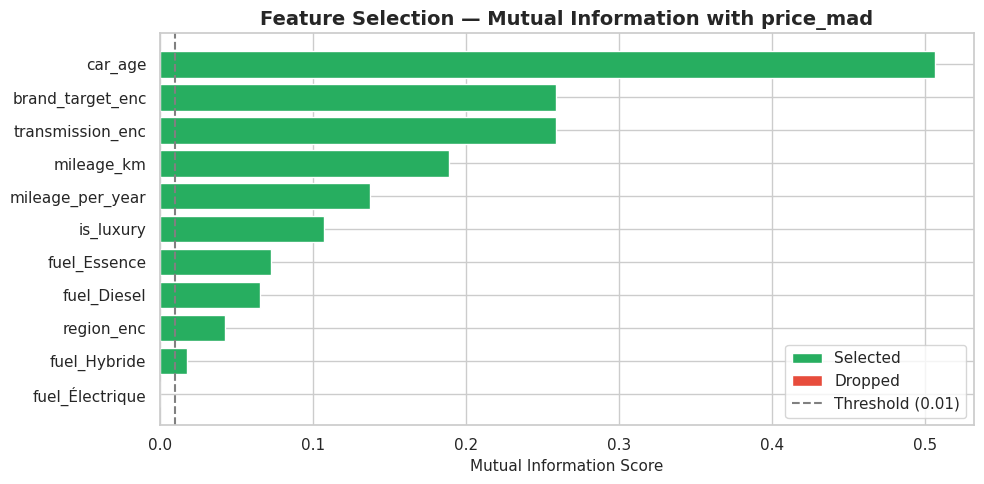

In [ ]:
# ── Feature importance bar chart ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#27ae60" if s >= THRESHOLD else "#e74c3c" for s in mi_series.values]
ax.barh(mi_series.index[::-1], mi_series.values[::-1], color=colors[::-1])
ax.axvline(x=THRESHOLD, color="gray", linestyle="--", linewidth=1.5, label=f"Threshold = {THRESHOLD}")
ax.set_title("Feature Selection — Mutual Information with price_mad", fontweight="bold")
ax.set_xlabel("Mutual Information Score")

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor="#27ae60", label="Selected"),
    Patch(facecolor="#e74c3c", label="Dropped"),
    plt.Line2D([0],[0], color="gray", linestyle="--", label=f"Threshold ({THRESHOLD})")
])
plt.tight_layout()
plt.show()


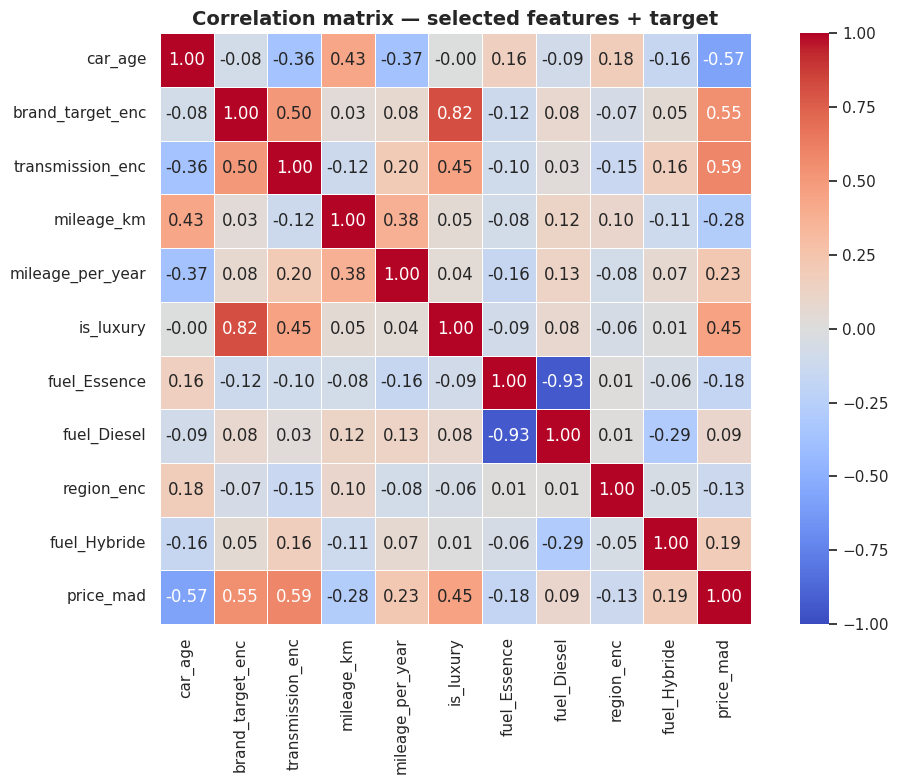


 Final feature matrix: 35,409 rows × 10 features


In [ ]:
# ── Correlation heatmap of selected features ──────────────
X_sel = X[selected_features]

corr = pd.concat([X_sel, y], axis=1).corr()
plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Correlation matrix — selected features + target", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\n Final feature matrix: {X_sel.shape[0]:,} rows × {X_sel.shape[1]} features")


---

## C.6 — Data Transformation: Normalization & Standardization

### Target transformation
Part B showed `price_mad` is **right-skewed** on a log scale.  
We apply `log1p` to make it more normally distributed — which helps linear models and gradient-boosted trees.

### Feature scaling
Three scalers are prepared depending on the model family used in Part D:

| Scaler | Formula | Recommended for |
|--------|---------|----------------|
| **StandardScaler** | (x − μ) / σ | Linear Regression, SVM, PCA |
| **MinMaxScaler** | (x − min) / (max − min) → [0, 1] | Neural Networks, KNN |
| **RobustScaler** | (x − median) / IQR | Default — robust to remaining outliers |


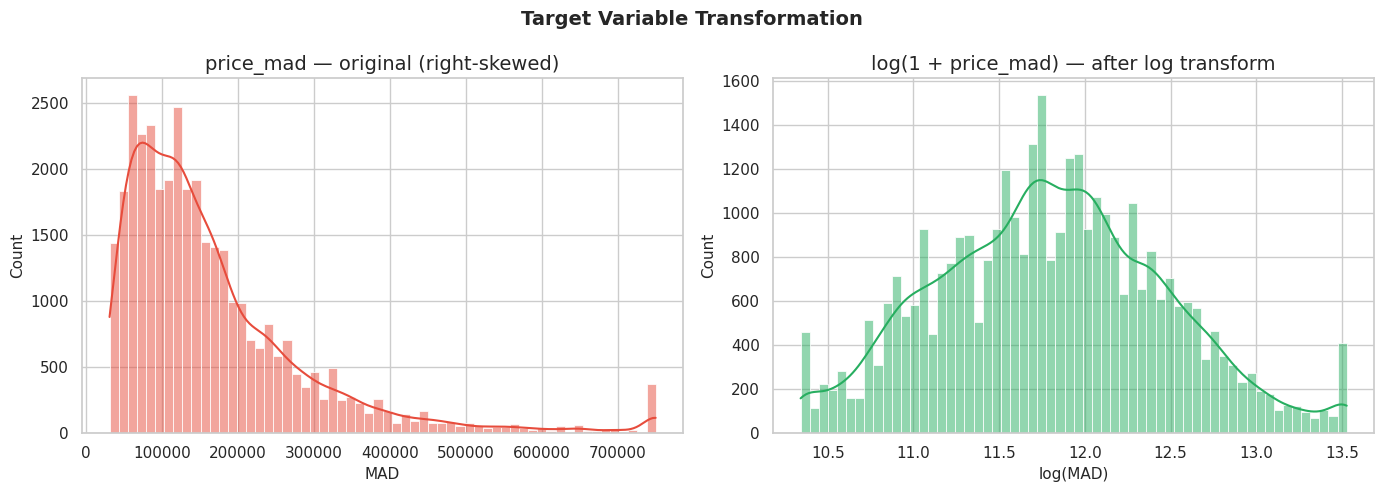

Skewness BEFORE log: 2.086
Skewness AFTER  log: 0.139  ✅ significantly reduced


In [ ]:
# ── Log-transform the target ─────────────────────────────
y_log = np.log1p(y)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(y, bins=60, kde=True, ax=axes[0], color="#e74c3c")
axes[0].set_title("price_mad — original (right-skewed)")
axes[0].set_xlabel("MAD")

sns.histplot(y_log, bins=60, kde=True, ax=axes[1], color="#27ae60")
axes[1].set_title("log(1 + price_mad) — after log transform")
axes[1].set_xlabel("log(MAD)")

plt.suptitle("Target Variable Transformation", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

skew_before = stats.skew(y)
skew_after  = stats.skew(y_log)
print(f"Skewness BEFORE log: {skew_before:.3f}")
print(f"Skewness AFTER  log: {skew_after:.3f}  ✅ significantly reduced")


In [ ]:
# ── Fit the three scalers ─────────────────────────────────
scaler_std = StandardScaler()
scaler_mm  = MinMaxScaler()
scaler_rb  = RobustScaler()

X_std  = pd.DataFrame(scaler_std.fit_transform(X_sel), columns=X_sel.columns)
X_mm   = pd.DataFrame(scaler_mm.fit_transform(X_sel),  columns=X_sel.columns)
X_rb   = pd.DataFrame(scaler_rb.fit_transform(X_sel),  columns=X_sel.columns)

print("StandardScaler — mean ≈ 0, std ≈ 1:")
display(X_std.describe().round(2))

print("\nMinMaxScaler — all values in [0, 1]:")
display(X_mm.describe().round(2))

print("\nRobustScaler — median = 0, IQR = 1:")
display(X_rb.describe().round(2))


StandardScaler — mean ≈ 0, std ≈ 1:


,car_age,brand_target_enc,transmission_enc,mileage_km,mileage_per_year,is_luxury,fuel_Essence,fuel_Diesel,region_enc,fuel_Hybride
count,35409.00,35409.00,35409.00,35409.00,35409.00,35409.00,35409.00,35409.00,35409.00,35409.00
mean,0.00,0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.72,-1.95,-0.80,-1.48,-1.38,-0.53,-0.42,-2.21,-1.30,-0.13
25%,-0.66,-0.76,-0.80,-0.74,-0.50,-0.53,-0.42,0.45,-0.99,-0.13
50%,-0.20,-0.25,-0.80,-0.07,-0.10,-0.53,-0.42,0.45,-0.06,-0.13
75%,0.56,0.18,1.25,0.63,0.35,-0.53,-0.42,0.45,0.87,-0.13
max,3.61,8.25,1.25,4.08,24.51,1.87,2.37,0.45,1.49,7.55



MinMaxScaler — all values in [0, 1]:


,car_age,brand_target_enc,transmission_enc,mileage_km,mileage_per_year,is_luxury,fuel_Essence,fuel_Diesel,region_enc,fuel_Hybride
count,35409.00,35409.00,35409.00,35409.00,35409.00,35409.00,35409.00,35409.00,35409.00,35409.00
mean,0.32,0.19,0.39,0.27,0.05,0.22,0.15,0.83,0.46,0.02
std,0.19,0.10,0.49,0.18,0.04,0.42,0.36,0.38,0.36,0.13
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.20,0.12,0.00,0.13,0.03,0.00,0.00,1.00,0.11,0.00
50%,0.29,0.17,0.00,0.25,0.05,0.00,0.00,1.00,0.44,0.00
75%,0.43,0.21,1.00,0.38,0.07,0.00,0.00,1.00,0.78,0.00
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00



RobustScaler — median = 0, IQR = 1:


,car_age,brand_target_enc,transmission_enc,mileage_km,mileage_per_year,is_luxury,fuel_Essence,fuel_Diesel,region_enc,fuel_Hybride
count,35409.00,35409.00,35409.00,35409.00,35409.00,35409.00,35409.00,35409.00,35409.00,35409.00
mean,0.16,0.27,0.39,0.05,0.12,0.22,0.15,-0.17,0.03,0.02
std,0.82,1.07,0.49,0.73,1.17,0.42,0.36,0.38,0.54,0.13
min,-1.25,-1.82,0.00,-1.03,-1.50,0.00,0.00,-1.00,-0.67,0.00
25%,-0.38,-0.54,0.00,-0.49,-0.47,0.00,0.00,0.00,-0.50,0.00
50%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,0.62,0.46,1.00,0.51,0.53,0.00,0.00,0.00,0.50,0.00
max,3.12,9.14,1.00,3.02,28.81,1.00,1.00,0.00,0.83,1.00


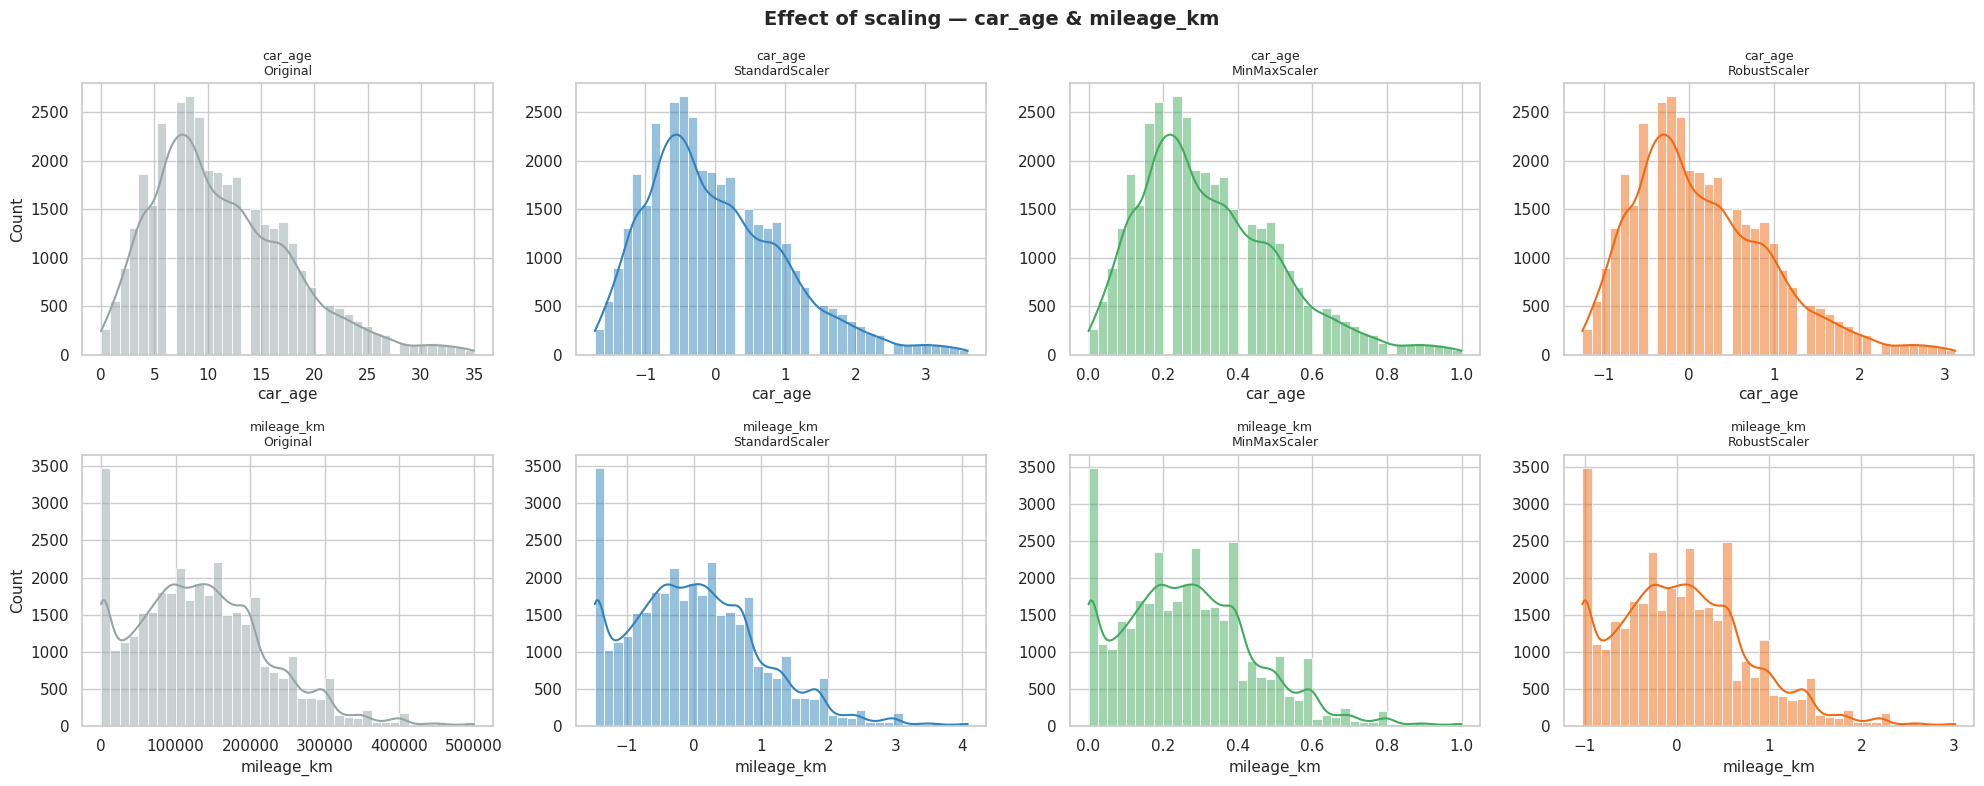

In [ ]:
# ── Compare effect of scaling on two key features ────────
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle("Effect of scaling — car_age & mileage_km", fontsize=14, fontweight="bold")

scalers_data = [
    (X_sel,  "Original",      "#95a5a6"),
    (X_std,  "StandardScaler", "#3182bd"),
    (X_mm,   "MinMaxScaler",   "#41ab5d"),
    (X_rb,   "RobustScaler",   "#f16913"),
]
for row, feat in enumerate(["car_age", "mileage_km"]):
    for col, (data, title, color) in enumerate(scalers_data):
        sns.histplot(data[feat], bins=40, ax=axes[row, col], color=color, kde=True)
        axes[row, col].set_title(f"{feat}\n{title}", fontsize=9)
        axes[row, col].set_ylabel("Count" if col == 0 else "")

plt.tight_layout()
plt.show()


---

## Save — Export Preprocessed Datasets

Three scaled versions of `X` plus both forms of `y` are exported as CSV files,  
ready to be loaded in **Part D (Model Building)**.


In [ ]:
y_out     = y.reset_index(drop=True)
y_log_out = y_log.reset_index(drop=True)

X_std.to_csv("X_standard.csv",  index=False)
X_mm.to_csv("X_minmax.csv",     index=False)
X_rb.to_csv("X_robust.csv",     index=False)
y_out.to_csv("y_price.csv",     index=False)
y_log_out.to_csv("y_price_log.csv", index=False)

print("✅ Saved:")
for f in ["X_standard.csv", "X_minmax.csv", "X_robust.csv", "y_price.csv", "y_price_log.csv"]:
    print(f"   • {f}")


✅ Saved:
   • X_standard.csv
   • X_minmax.csv
   • X_robust.csv
   • y_price.csv
   • y_price_log.csv


---

## Summary

| Step | Action | Rows in | Rows out |
|------|--------|---------|---------|
| Load (Part B) | Raw CSV | 38 868 | 38 868 |
| C.1 Missing | Drop missing target; impute others | 38 868 | 36 214 |
| C.2 Outliers | Year 1990–2025 · mileage ≤ 500 000 · price 5k–5M + Winsorise | 36 214 | ≈ 35 400 |
| C.3 Engineering | +5 new features (car_age, brand, mileage_per_year, is_luxury, region) | — | — |
| C.4 Encoding | OHE (fuel) · Binary (transmission) · Label (region) · Target (brand) | — | 11 features |
| C.5 Selection | Mutual Information ≥ 0.01 | 11 | **10 features** |
| C.6 Transform | log(target) · StandardScaler / MinMaxScaler / RobustScaler | — | 3 scaled versions |

### Key findings from Mutual Information
- **`car_age`** (MI ≈ 0.51) — strongest predictor; confirms Part B scatterplot (year vs price)
- **`transmission_enc`** & **`brand_target_enc`** (MI ≈ 0.27) — automatics and premium brands both drive price up
- **`mileage_km`** & **`mileage_per_year`** (MI ≈ 0.18 / 0.14) — complementary mileage signals
- **`fuel_Électrique`** dropped (MI < 0.01) — only 132 EVs in dataset, insufficient signal